# Shape × Many Colors Forward Transfer — panels for figure 4 and some supplement

Inputs:
* `shape_color_transfer_TIMESTAMP_all_trials.csv` — per-trial output of
  the single-parameter runner (one row per trial × seed).
* `shape_color_sweep_TIMESTAMP_per_seed.csv` — per-seed output of the
  parameter sweep (one row per (alpha, omega, seed)).

In [2]:
# =====================================================================
# Imports and global style.
# =====================================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.interpolate import griddata

os.makedirs('plots', exist_ok=True)

# Colors used throughout.
COLOR_FLAT = "#4D4B4B"
COLOR_HIER = "#7C3AED"
COLOR_HIER_LIGHT = "#EDA7FF"
COLOR_FLAT_LIGHT = "#7A7979"

sns.set_style("whitegrid")
sns.set_context("talk")

ALL_TRIALS_CSV = 'shape_color_transfer_20260612_115331_all_trials.csv'
SWEEP_CSV      = 'shape_color_sweep_20260611_2009_per_seed.csv'

## Part 1 — Single-parameter analysis (one (α, Ω), many seeds)

Load the per-trial CSV, compute per-seed metrics, run paired tests, plot.

In [3]:
# =====================================================================
# Load and validate the per-trial CSV.
# =====================================================================
trials = pd.read_csv(ALL_TRIALS_CSV)

expected_cols = {
    'seed', 'rewarded_shape', 'trial', 'phase', 'shape', 'color',
    'is_first_heldout', 'reward',
    'flat_prob', 'hier_prob',
    'flat_correct', 'hier_correct',
}
missing = expected_cols - set(trials.columns)
if missing:
    raise ValueError(f"Per-trial CSV is missing columns: {missing}")

print(f"Loaded {len(trials)} per-trial rows from {ALL_TRIALS_CSV}")
print(f"  seeds: {trials['seed'].nunique()}")
print(f"  phases: {sorted(trials['phase'].unique())}")
print(f"  rewarded_shape values: {sorted(trials['rewarded_shape'].unique())}")
print(f"  first-heldout trials: {int(trials['is_first_heldout'].sum())} "
      f"({int(trials['is_first_heldout'].sum()) / trials['seed'].nunique():.1f} per seed avg)")

Loaded 16800 per-trial rows from shape_color_transfer_20260612_115331_all_trials.csv
  seeds: 200
  phases: ['test', 'train']
  rewarded_shape values: [0]
  first-heldout trials: 800 (4.0 per seed avg)


In [4]:
# =====================================================================
# Per-seed aggregation.
# Each seed contributes one value per metric. All downstream tests treat
# seeds as the unit of replication (paired across flat/hier).
# =====================================================================

def _brier(prob, reward):
    return float(np.mean((np.asarray(prob) - np.asarray(reward, float)) ** 2))

def _logloss(prob, reward, eps=1e-9):
    p = np.clip(np.asarray(prob, float), eps, 1 - eps)
    r = np.asarray(reward, float)
    return float(np.mean(-(r * np.log(p) + (1 - r) * np.log(1 - p))))

def _signed_shape_contrast(probs, shapes, rewarded_shape):
    """Mean p(reward | rewarded_shape) - mean p(reward | other shape).
    Sign-corrected: positive = model reads the rewarded shape.
    Returns NaN if either shape has no trials."""
    sign = 1 if rewarded_shape == 0 else -1
    p0 = probs[shapes == 0]
    p1 = probs[shapes == 1]
    if len(p0) == 0 or len(p1) == 0:
        return np.nan
    return float(sign * (p0.mean() - p1.mean()))

rows = []
for seed, grp in trials.groupby('seed'):
    rs = int(grp['rewarded_shape'].iloc[0])
    train_grp = grp[grp['phase'] == 'train']
    held_grp  = grp[grp['is_first_heldout'].astype(bool)]
    if len(held_grp) == 0:
        continue

    rows.append({
        'seed': seed,
        'rewarded_shape': rs,
        'n_heldout_trials': len(held_grp),
        # held-out accuracy (binary correct, averaged within seed)
        'flat_heldout_acc': float(held_grp['flat_correct'].mean()),
        'hier_heldout_acc': float(held_grp['hier_correct'].mean()),
        # signed shape contrast: training and held-out
        'flat_train_signed': _signed_shape_contrast(
            train_grp['flat_prob'].values, train_grp['shape'].values, rs),
        'hier_train_signed': _signed_shape_contrast(
            train_grp['hier_prob'].values, train_grp['shape'].values, rs),
        'flat_heldout_signed': _signed_shape_contrast(
            held_grp['flat_prob'].values, held_grp['shape'].values, rs),
        'hier_heldout_signed': _signed_shape_contrast(
            held_grp['hier_prob'].values, held_grp['shape'].values, rs),
        # Brier + log-loss on held-out
        'flat_heldout_brier': _brier(held_grp['flat_prob'].values,
                                     held_grp['reward'].values),
        'hier_heldout_brier': _brier(held_grp['hier_prob'].values,
                                     held_grp['reward'].values),
        'flat_heldout_logloss': _logloss(held_grp['flat_prob'].values,
                                         held_grp['reward'].values),
        'hier_heldout_logloss': _logloss(held_grp['hier_prob'].values,
                                         held_grp['reward'].values),
    })

per_seed = pd.DataFrame(rows)

# Per-seed transfer ratio: each seed's held-out contrast divided by THAT
# seed's HOLMES training contrast.
# We mask seeds whose HOLMES training contrast is too small for the ratio
# to be meaningful (avoids divide-by-near-zero).
MIN_TRAIN = 0.001
valid = np.abs(per_seed['hier_train_signed']) > MIN_TRAIN
per_seed['flat_transfer_ratio'] = np.where(
    valid, per_seed['flat_heldout_signed'] / per_seed['hier_train_signed'], np.nan)
per_seed['hier_transfer_ratio'] = np.where(
    valid, per_seed['hier_heldout_signed'] / per_seed['hier_train_signed'], np.nan)
n_excl = int((~valid).sum())
if n_excl:
    print(f"  Excluded {n_excl}/{len(per_seed)} seeds from transfer ratio "
          f"(|HOLMES training contrast| < {MIN_TRAIN})")

print(f"\nPer-seed dataframe: {len(per_seed)} seeds × {per_seed.shape[1]} columns")
per_seed.head()


Per-seed dataframe: 200 seeds × 15 columns


,seed,rewarded_shape,n_heldout_trials,flat_heldout_acc,hier_heldout_acc,flat_train_signed,hier_train_signed,flat_heldout_signed,hier_heldout_signed,flat_heldout_brier,hier_heldout_brier,flat_heldout_logloss,hier_heldout_logloss,flat_transfer_ratio,hier_transfer_ratio
0,0,0,4,0.75,0.75,0.276163,0.275603,0.008599,0.020447,0.245738,0.239923,0.684621,0.672988,0.031199,0.074191
1,1,0,4,0.75,1.00,0.281851,0.324343,0.020569,0.085307,0.239912,0.209327,0.672961,0.611553,0.063417,0.263014
2,2,0,4,0.25,1.00,0.278505,0.311091,-0.000332,0.053280,0.250180,0.224306,0.693508,0.641662,-0.001068,0.171267
3,3,0,4,0.50,1.00,0.275483,0.298303,-0.006139,0.029988,0.253104,0.235255,0.699356,0.663645,-0.020579,0.100530
4,4,0,4,1.00,1.00,0.287376,0.310906,0.019477,0.094581,0.240394,0.205119,0.673930,0.603067,0.062646,0.304210


In [5]:
# =====================================================================
# Paired comparison helper. Uses paired t on the per-seed differences
# and reports Cohen's d on the paired contrast.
# =====================================================================

def paired_report(flat_vals, hier_vals, label, higher_is_better=True):
    flat = np.asarray(flat_vals, float)
    hier = np.asarray(hier_vals, float)
    mask = np.isfinite(flat) & np.isfinite(hier)
    flat, hier = flat[mask], hier[mask]
    n = len(flat)
    if n < 2:
        print(f"{label}: insufficient data ({n} valid seeds)")
        return
    diff = hier - flat
    t_stat, p_val = stats.ttest_rel(hier, flat)
    d = float(np.mean(diff) / np.std(diff, ddof=1)) if np.std(diff, ddof=1) > 0 else np.nan
    t_crit = stats.t.ppf(0.975, df=n - 1)
    flat_ci = t_crit * stats.sem(flat)
    hier_ci = t_crit * stats.sem(hier)
    diff_ci = t_crit * stats.sem(diff)
    arrow = '↑' if (np.mean(diff) > 0) == higher_is_better else '↓'
    print(f"\n{label}")
    print(f"  flat  : {flat.mean():+.4f} ± {flat_ci:.4f} (95% CI, n={n})")
    print(f"  HOLMES: {hier.mean():+.4f} ± {hier_ci:.4f} (95% CI, n={n})")
    print(f"  diff  : {np.mean(diff):+.4f} ± {diff_ci:.4f} {arrow}")
    print(f"  paired t({n-1})={t_stat:+.3f}, p={p_val:.2e}, d={d:+.3f}")

paired_report(per_seed['flat_heldout_acc'],     per_seed['hier_heldout_acc'],
              'First-heldout accuracy')
paired_report(per_seed['flat_heldout_signed'],  per_seed['hier_heldout_signed'],
              'Signed shape contrast on novel colors')
paired_report(per_seed['flat_transfer_ratio'],  per_seed['hier_transfer_ratio'],
              'Transfer ratio (per-seed denominator)')
paired_report(per_seed['flat_heldout_brier'],   per_seed['hier_heldout_brier'],
              'Held-out Brier (lower=better)', higher_is_better=False)
paired_report(per_seed['flat_heldout_logloss'], per_seed['hier_heldout_logloss'],
              'Held-out log loss (lower=better)', higher_is_better=False)


First-heldout accuracy
  flat  : +0.5437 ± 0.0323 (95% CI, n=200)
  HOLMES: +0.9263 ± 0.0197 (95% CI, n=200)
  diff  : +0.3825 ± 0.0412 ↑
  paired t(199)=+18.313, p=1.48e-44, d=+1.295

Signed shape contrast on novel colors
  flat  : +0.0023 ± 0.0011 (95% CI, n=200)
  HOLMES: +0.0408 ± 0.0029 (95% CI, n=200)
  diff  : +0.0385 ± 0.0031 ↑
  paired t(199)=+24.738, p=1.27e-62, d=+1.749

Transfer ratio (per-seed denominator)
  flat  : +0.0079 ± 0.0039 (95% CI, n=200)
  HOLMES: +0.1405 ± 0.0094 (95% CI, n=200)
  diff  : +0.1326 ± 0.0102 ↑
  paired t(199)=+25.719, p=3.46e-65, d=+1.819

Held-out Brier (lower=better)
  flat  : +0.2489 ± 0.0005 (95% CI, n=200)
  HOLMES: +0.2302 ± 0.0014 (95% CI, n=200)
  diff  : -0.0187 ± 0.0015 ↑
  paired t(199)=-25.182, p=8.62e-64, d=-1.781

Held-out log loss (lower=better)
  flat  : +0.6910 ± 0.0011 (95% CI, n=200)
  HOLMES: +0.6536 ± 0.0027 (95% CI, n=200)
  diff  : -0.0374 ± 0.0029 ↑
  paired t(199)=-25.140, p=1.11e-63, d=-1.778



Statistics for '':
  Flat:  0.54 ± 0.03 (95% CI)
  Hier:  0.93 ± 0.02 (95% CI)
  Diff:  +0.38
  t(199) = 18.313, p = 1.48e-44


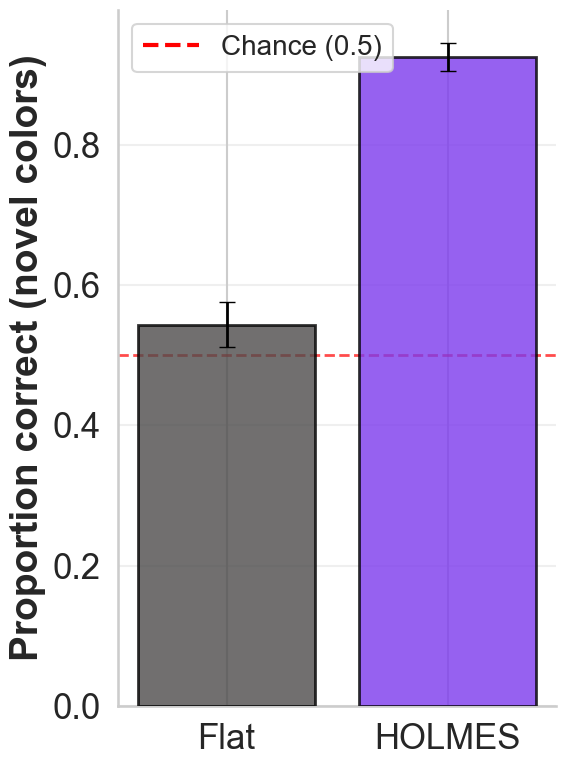


Statistics for '':
  Flat:  0.00 ± 0.00 (95% CI)
  Hier:  0.04 ± 0.00 (95% CI)
  Diff:  +0.04
  t(199) = 24.738, p = 1.27e-62


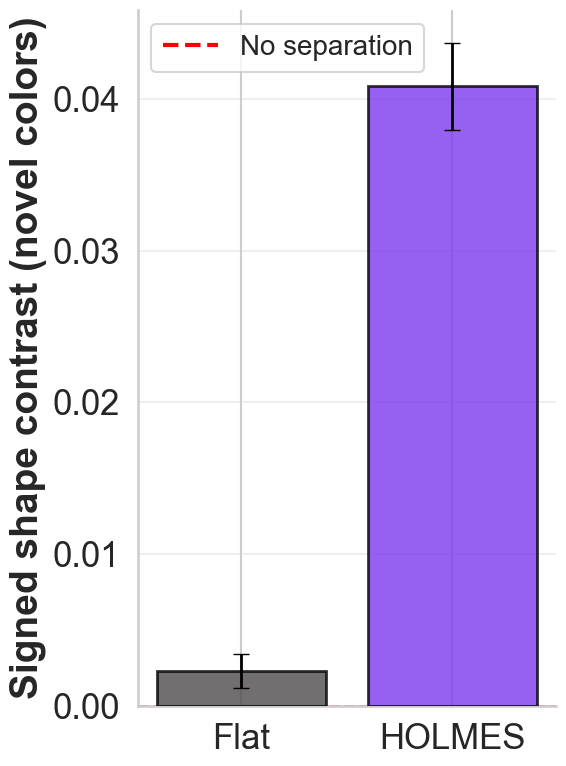


Statistics for '':
  Flat:  0.01 ± 0.00 (95% CI)
  Hier:  0.14 ± 0.01 (95% CI)
  Diff:  +0.13
  t(199) = 25.719, p = 3.46e-65


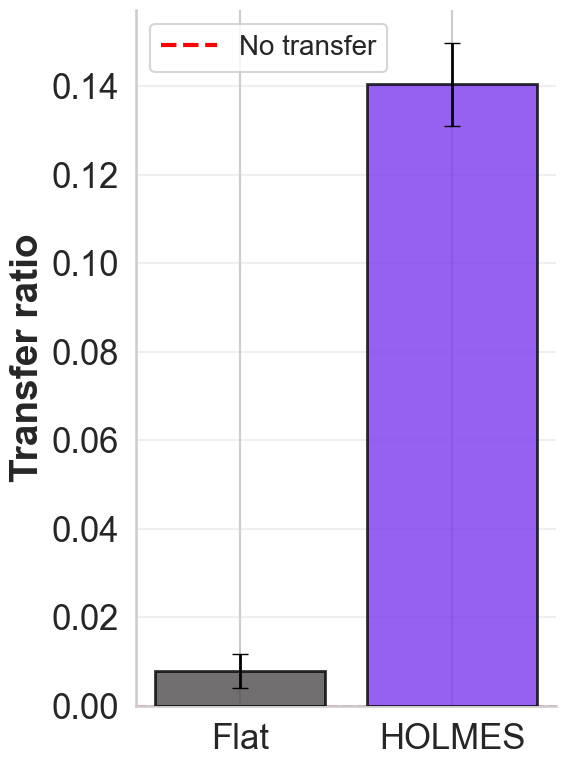

In [6]:
from bar_plot import create_bar_plot

create_bar_plot(per_seed['flat_heldout_acc'], per_seed['hier_heldout_acc'], title = '',
                 ylabel='Proportion correct (novel colors)',show_points=False,
                 optimal_line=0.5, line_label='Chance (0.5)');

create_bar_plot(per_seed['flat_heldout_signed'], per_seed['hier_heldout_signed'], title = '',
                 ylabel='Signed shape contrast (novel colors)', show_points=False,
                 optimal_line=0.0, line_label='No separation');

create_bar_plot(per_seed['flat_transfer_ratio'], per_seed['hier_transfer_ratio'],title = '',
                 ylabel='Transfer ratio', show_points=False,  
                 optimal_line=0.0, line_label='No transfer');

### Threshold-free confirmation: AUC alongside accuracy
Accuracy is reported at the task-appropriate 0.5 boundary (balanced reward → Bayes threshold 0.5). AUC confirms the effect does not depend on that threshold.

In [7]:
# =====================================================================
# AUC (threshold-free) on novel-color held-out trials.
#
# AUC = P(a rewarded-shape item is ranked above an other-shape item).
# It answers the same "which side of the line?" question as accuracy, but
# averaged over ALL thresholds, so it does not depend on the 0.5 cut being
# the right boundary. We report:
#   * per-seed AUC  -> for the paired test (seed = unit of replication)
#   * pooled AUC    -> the robust headline number across all held-out trials,
#                      with a bootstrap 95% CI (per-seed AUC is noisy when a
#                      seed has few held-out trials; pooling removes that).
# Sign convention matches _signed_shape_contrast: positive class = the
# rewarded shape's items, "score" = model's p(reward).
# =====================================================================
from sklearn.metrics import roc_auc_score

def _auc_reward_vs_other(probs, shapes, rewarded_shape):
    """AUC for separating rewarded-shape items (label 1) from other (label 0),
    using p(reward) as the score. Returns NaN if a class is empty."""
    probs = np.asarray(probs, float)
    lab = (np.asarray(shapes) == rewarded_shape).astype(int)
    if lab.sum() == 0 or lab.sum() == len(lab):
        return np.nan
    return float(roc_auc_score(lab, probs))

# per-seed AUC, merged into per_seed
_auc_rows = []
for seed, grp in trials.groupby('seed'):
    rs = int(grp['rewarded_shape'].iloc[0])
    held_grp = grp[grp['is_first_heldout'].astype(bool)]
    if len(held_grp) == 0:
        continue
    _auc_rows.append({
        'seed': seed,
        'flat_heldout_auc': _auc_reward_vs_other(
            held_grp['flat_prob'].values, held_grp['shape'].values, rs),
        'hier_heldout_auc': _auc_reward_vs_other(
            held_grp['hier_prob'].values, held_grp['shape'].values, rs),
    })
_auc_df = pd.DataFrame(_auc_rows)
per_seed = per_seed.merge(_auc_df, on='seed', how='left')

# pooled AUC across ALL held-out trials (headline), + bootstrap 95% CI over seeds
held_all = trials[trials['is_first_heldout'].astype(bool)].copy()
# sign-correct: relabel so "positive" is always the rewarded shape
held_all['is_rewarded_item'] = (held_all['shape'] == held_all['rewarded_shape']).astype(int)

def _pooled_auc(df, prob_col):
    return roc_auc_score(df['is_rewarded_item'].values, df[prob_col].values)

def _bootstrap_auc_ci(df, prob_col, n_boot=2000, seed=0):
    rng = np.random.default_rng(seed)
    seeds = df['seed'].unique()
    vals = []
    for _ in range(n_boot):
        take = rng.choice(seeds, len(seeds), replace=True)
        sub = pd.concat([df[df['seed'] == s] for s in take], ignore_index=True)
        if sub['is_rewarded_item'].nunique() < 2:
            continue
        vals.append(roc_auc_score(sub['is_rewarded_item'].values, sub[prob_col].values))
    return float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))

flat_pool_auc = _pooled_auc(held_all, 'flat_prob')
hier_pool_auc = _pooled_auc(held_all, 'hier_prob')
flat_auc_lo, flat_auc_hi = _bootstrap_auc_ci(held_all, 'flat_prob')
hier_auc_lo, hier_auc_hi = _bootstrap_auc_ci(held_all, 'hier_prob')

print("Pooled held-out AUC (all novel-color trials; bootstrap 95% CI over seeds):")
print(f"  Flat  : {flat_pool_auc:.3f}  [{flat_auc_lo:.3f}, {flat_auc_hi:.3f}]")
print(f"  HOLMES: {hier_pool_auc:.3f}  [{hier_auc_lo:.3f}, {hier_auc_hi:.3f}]")
print("\nPer-seed AUC added to per_seed as flat_heldout_auc / hier_heldout_auc.")


Pooled held-out AUC (all novel-color trials; bootstrap 95% CI over seeds):
  Flat  : 0.571  [0.532, 0.607]
  HOLMES: 0.984  [0.977, 0.990]

Per-seed AUC added to per_seed as flat_heldout_auc / hier_heldout_auc.


In [8]:

paired_report(per_seed['flat_heldout_auc'], per_seed['hier_heldout_auc'],
              'Held-out AUC (threshold-free)')



Held-out AUC (threshold-free)
  flat  : +0.5400 ± 0.0487 (95% CI, n=200)
  HOLMES: +0.9912 ± 0.0088 (95% CI, n=200)
  diff  : +0.4512 ± 0.0501 ↑
  paired t(199)=+17.754, p=6.85e-43, d=+1.255


In [11]:
# =====================================================================
# McNemar test on paired trial outcomes (held-out trials only).
# Trials are paired because both models predict on the same held-out trial.
# =====================================================================
held = trials[trials['is_first_heldout'].astype(bool)].copy()

both     = ((held['flat_correct'] == 1) & (held['hier_correct'] == 1)).sum()
flat_only = ((held['flat_correct'] == 1) & (held['hier_correct'] == 0)).sum()
hier_only = ((held['flat_correct'] == 0) & (held['hier_correct'] == 1)).sum()
neither  = ((held['flat_correct'] == 0) & (held['hier_correct'] == 0)).sum()

print(f"Total held-out trials (across seeds): {len(held)}")
print(f"  both correct      : {both}")
print(f"  flat only correct : {flat_only}")
print(f"  HOLMES only correct: {hier_only}")
print(f"  both wrong        : {neither}")

# Two-sided exact McNemar via binomial test on discordant pairs.
if hier_only + flat_only > 0:
    bt = stats.binomtest(hier_only, hier_only + flat_only, p=0.5,
                         alternative='two-sided')
    print(f"\nMcNemar exact (two-sided): p = {bt.pvalue:.2e}")
    print(f"  discordant pairs: {hier_only + flat_only} "
          f"(HOLMES-only: {hier_only}, flat-only: {flat_only})")

Total held-out trials (across seeds): 800
  both correct      : 412
  flat only correct : 23
  HOLMES only correct: 329
  both wrong        : 36

McNemar exact (two-sided): p = 1.62e-70
  discordant pairs: 352 (HOLMES-only: 329, flat-only: 23)


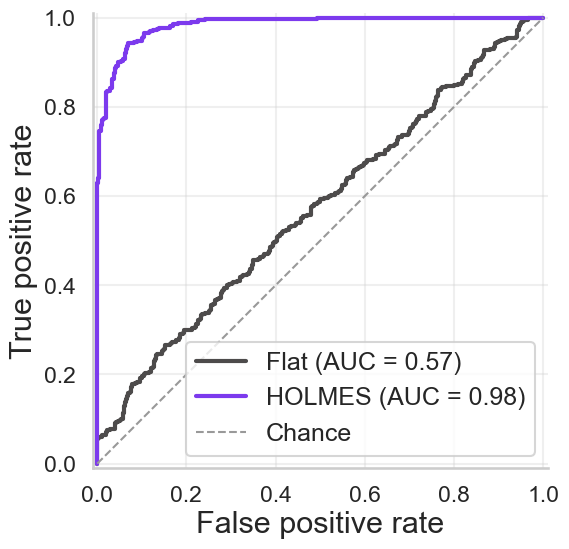

In [13]:
# =====================================================================
# FIGURE 4 — five independent plot cells.
# Each cell is self-contained: it loads only the notebook variables that
# already exist (`trials` = per-trial 200-seed CSV at the operating point;
# `sweep` = the 200-cell shape/color sweep), makes ONE plot, and saves its
# own file. Drop them into the notebook in whatever order you want; nothing
# here depends on the order they run in.
#
# Expected preexisting variables:
#   trials : DataFrame of per-trial rows (cols: is_first_heldout, flat_prob,
#            hier_prob, shape, rewarded_shape)
#   sweep  : DataFrame of the 200-cell sweep (cols include
#            adv_heldout_signed_contrast, hier_best_shape_level, ...)
#   COLOR_FLAT, COLOR_HIER : the paper palette
# If `sweep` isn't loaded yet:  sweep = pd.read_csv('shape_color_sweep_...csv')
# =====================================================================
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
os.makedirs('plots', exist_ok=True)

COLOR_FLAT = globals().get('COLOR_FLAT', '#4D4B4B')
COLOR_HIER = globals().get('COLOR_HIER', '#7C3AED')
COLOR_HIER_LT = '#c9b3ec'   # light purple for the "other shape" cloud

# Shared helper: pooled, sign-corrected held-out frame from `trials`
def _heldout_frame():
    h = trials[trials['is_first_heldout'].astype(bool)].copy()
    h['is_rew'] = (h['shape'] == h['rewarded_shape']).astype(int)
    return h


# ---------------------------------------------------------------------
# PLOT 1 — ROC curves (threshold-free effect at the operating point)
# ---------------------------------------------------------------------
def plot_roc():
    h = _heldout_frame()
    fig, ax = plt.subplots(figsize=(6, 6))
    for col, color, name in [('flat_prob', COLOR_FLAT, 'Flat'),
                             ('hier_prob', COLOR_HIER, 'HOLMES')]:
        fpr, tpr, _ = roc_curve(h['is_rew'], h[col])
        auc = roc_auc_score(h['is_rew'], h[col])
        ax.plot(fpr, tpr, color=color, lw=3, label=f'{name} (AUC = {auc:.2f})')
    ax.plot([0, 1], [0, 1], ls='--', color='#999', lw=1.5, label='Chance')
    ax.set_xlabel('False positive rate', fontsize=22)
    ax.set_ylabel('True positive rate', fontsize=22)
    #ax.set_title('ROC: novel-color generalization', fontsize=15)
    ax.legend(fontsize=18, loc='lower right')
    ax.set_xlim(-.01, 1.01); ax.set_ylim(-.01, 1.01); ax.set_aspect('equal')
    ax.spines[['top', 'right']].set_visible(False); ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig('plots/fig4_roc.png', dpi=200, bbox_inches='tight')
    fig.savefig('plots/fig4_roc.pdf', bbox_inches='tight')
    plt.show()

plot_roc()

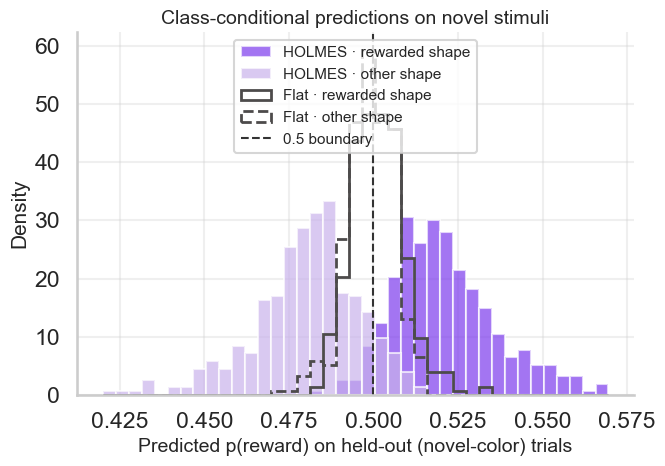

In [14]:
# ---------------------------------------------------------------------
# PLOT 2 — held-out prediction distributions by class (why 0.5 is justified)
# Shows the two class-conditional p(reward) clouds for HOLMES with the 0.5
# line. The separation (rewarded cloud shifted right of other) with 0.5
# falling between them is what makes thresholded accuracy meaningful here.
# Flat shown as faint outline for contrast (its clouds sit on top of 0.5).
# ---------------------------------------------------------------------
import os, numpy as np
import matplotlib.pyplot as plt
os.makedirs('plots', exist_ok=True)
COLOR_FLAT = globals().get('COLOR_FLAT', '#4D4B4B')
COLOR_HIER = globals().get('COLOR_HIER', '#7C3AED')
COLOR_HIER_LT = '#c9b3ec'

def plot_dist(show_flat=True):
    h = trials[trials['is_first_heldout'].astype(bool)].copy()
    h['is_rew'] = (h['shape'] == h['rewarded_shape']).astype(int)
    lo = h[['flat_prob', 'hier_prob']].min().min()
    hi = h[['flat_prob', 'hier_prob']].max().max()
    bins = np.linspace(lo, hi, 40)

    fig, ax = plt.subplots(figsize=(7, 5))
    # HOLMES filled
    ax.hist(h.loc[h.is_rew == 1, 'hier_prob'], bins=bins, density=True,
            alpha=0.7, color=COLOR_HIER, label='HOLMES · rewarded shape')
    ax.hist(h.loc[h.is_rew == 0, 'hier_prob'], bins=bins, density=True,
            alpha=0.7, color=COLOR_HIER_LT, label='HOLMES · other shape')
    if show_flat:
        # flat as step outlines so it doesn't obscure HOLMES
        ax.hist(h.loc[h.is_rew == 1, 'flat_prob'], bins=bins, density=True,
                histtype='step', lw=2, color=COLOR_FLAT, label='Flat · rewarded shape')
        ax.hist(h.loc[h.is_rew == 0, 'flat_prob'], bins=bins, density=True,
                histtype='step', lw=2, ls='--', color=COLOR_FLAT, label='Flat · other shape')
    ax.axvline(0.5, color='#333', ls='--', lw=1.5, label='0.5 boundary')
    ax.set_xlabel('Predicted p(reward) on held-out (novel-color) trials', fontsize=14)
    ax.set_ylabel('Density', fontsize=15)
    ax.set_title('Class-conditional predictions on novel stimuli', fontsize=14)
    ax.legend(fontsize=11, loc='upper center')
    ax.spines[['top', 'right']].set_visible(False); ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig('plots/fig4_distributions.png', dpi=200, bbox_inches='tight')
    fig.savefig('plots/fig4_distributions.pdf', bbox_inches='tight')
    plt.show()

plot_dist(show_flat=True)   # set show_flat=False for HOLMES-only (less clutter)

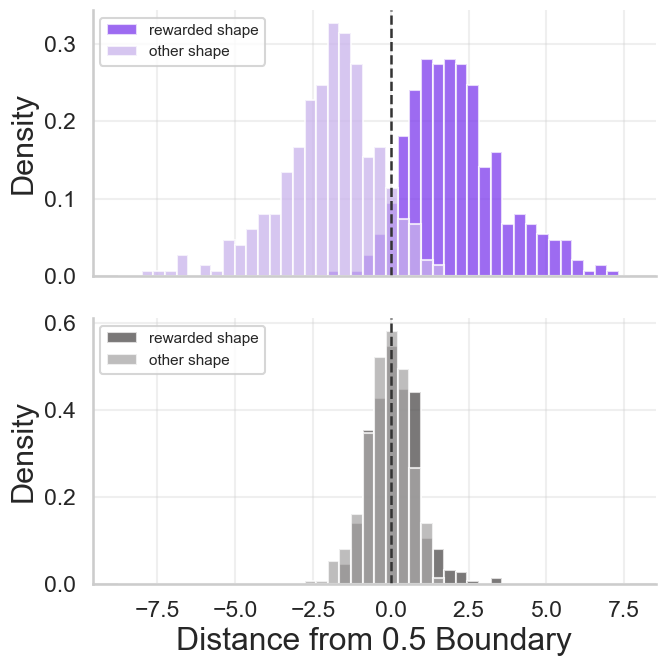

In [16]:
# ---------------------------------------------------------------------
# PLOT 2 — held-out prediction distributions by class, centered on the
# 0.5 boundary. Values are plotted as (p(reward) − 0.5) × 100, i.e. in
# percentage points away from indifference. This is a pure SHIFT and
# rescale-by-a-constant (identical for both models), so it does not distort
# the comparison: HOLMES's separation really is ~20x flat's, and that stays
# visible. The boundary is the vertical line at 0.
# ---------------------------------------------------------------------
import os, numpy as np
import matplotlib.pyplot as plt
os.makedirs('plots', exist_ok=True)
COLOR_FLAT = globals().get('COLOR_FLAT', '#4D4B4B')
COLOR_HIER = globals().get('COLOR_HIER', '#7C3AED')
COLOR_HIER_LT = '#c9b3ec'
COLOR_FLAT_LT = '#a9a7a7'

def plot_dist_centered(separate_panels=True):
    h = trials[trials['is_first_heldout'].astype(bool)].copy()
    h['is_rew'] = (h['shape'] == h['rewarded_shape']).astype(int)
    for c in ['flat_prob', 'hier_prob']:
        h[c + '_pp'] = (h[c] - 0.5) * 100          # percentage points from 0.5

    lo = min(h['flat_prob_pp'].min(), h['hier_prob_pp'].min())
    hi = max(h['flat_prob_pp'].max(), h['hier_prob_pp'].max())
    pad = 0.05 * (hi - lo)
    bins = np.linspace(lo - pad, hi + pad, 45)

    if separate_panels:
        fig, axes = plt.subplots(2, 1, figsize=(7, 7), sharex=True)
        specs = [(axes[0], 'hier_prob_pp', 'HOLMES', COLOR_HIER, COLOR_HIER_LT),
                 (axes[1], 'flat_prob_pp', 'Flat',   COLOR_FLAT, COLOR_FLAT_LT)]
    else:
        fig, ax = plt.subplots(figsize=(7.5, 5))
        specs = [(ax, 'hier_prob_pp', 'HOLMES', COLOR_HIER, COLOR_HIER_LT)]

    for ax, col, name, c_rew, c_oth in specs:
        ax.hist(h.loc[h.is_rew == 1, col], bins=bins, density=True, alpha=0.75,
                color=c_rew, label=f'rewarded shape')
        ax.hist(h.loc[h.is_rew == 0, col], bins=bins, density=True, alpha=0.75,
                color=c_oth, label=f'other shape')
        ax.axvline(0, color='#333', ls='--', lw=1.8)
        # # annotate the class means so the separation is quantified on the plot
        # m1 = h.loc[h.is_rew == 1, col].mean(); m0 = h.loc[h.is_rew == 0, col].mean()
        # ax.plot([m0, m1], [ax.get_ylim()[1]*0.92]*2, 'k|', ms=12)
        # ax.annotate('', xy=(m1, ax.get_ylim()[1]*0.92), xytext=(m0, ax.get_ylim()[1]*0.92),
        #             arrowprops=dict(arrowstyle='<->', color='k', lw=1.2))
        # ax.text((m0+m1)/2, ax.get_ylim()[1]*0.95, f'Δ = {m1-m0:.1f} pp',
        #         ha='center', fontsize=11)
        ax.set_ylabel('Density', fontsize=22)
        ax.legend(fontsize=11, loc='upper left')
        ax.spines[['top', 'right']].set_visible(False); ax.grid(alpha=0.3)

    (axes[-1] if separate_panels else ax).set_xlabel(
        'Distance from 0.5 Boundary', fontsize = 23)#'Predicted p(reward) − 0.5  (percentage points)', fontsize=23)
    #fig.suptitle('Held-out (novel-color) predictions by true class', fontsize=14)
    fig.tight_layout()

    plt.show()

plot_dist_centered(separate_panels=True)

## Part 2 — Parameter sweep analysis

Load the per-seed sweep CSV (one row per (α, Ω, seed)), aggregate to
per-(α, Ω) means, and plot heatmaps + the four-panel robustness figure.

In [16]:
# =====================================================================
# Load sweep CSV. The runner writes the signed-contrast columns already;
# we use those directly rather than re-applying the sign correction.
# =====================================================================
sweep_raw = pd.read_csv(SWEEP_CSV)

expected = {
    'alpha', 'omega', 'seed', 'rewarded_shape',
    'flat_train_signed_contrast', 'hier_train_signed_contrast',
    'flat_heldout_signed_contrast', 'hier_heldout_signed_contrast',
    'flat_first_heldout_acc', 'hier_first_heldout_acc',
    'flat_heldout_brier', 'hier_heldout_brier',
    'adv_first_heldout_acc',
    'adv_heldout_brier_reduction',
    'adv_heldout_signed_contrast',
}
missing = expected - set(sweep_raw.columns)
if missing:
    raise ValueError(f"Sweep CSV is missing columns: {missing}\n"
                     f"Present columns: {sorted(sweep_raw.columns)}")

# ── Per-seed transfer ratio (correct denominator) ─────────────────────
MIN_TRAIN = 0.001
valid = np.abs(sweep_raw['hier_train_signed_contrast']) > MIN_TRAIN
sweep_raw['flat_transfer_ratio'] = np.where(
    valid,
    sweep_raw['flat_heldout_signed_contrast'] / sweep_raw['hier_train_signed_contrast'],
    np.nan)
sweep_raw['hier_transfer_ratio'] = np.where(
    valid,
    sweep_raw['hier_heldout_signed_contrast'] / sweep_raw['hier_train_signed_contrast'],
    np.nan)
sweep_raw['adv_transfer_ratio'] = sweep_raw['hier_transfer_ratio'] - sweep_raw['flat_transfer_ratio']

n_excl = int((~valid).sum())
if n_excl:
    print(f"Excluded {n_excl}/{len(sweep_raw)} seed-rows from transfer ratio "
          f"(|HOLMES training contrast| < {MIN_TRAIN})")

# ── Aggregate to one row per (alpha, omega) ───────────────────────────
agg_cols = [
    'adv_transfer_ratio', 'hier_transfer_ratio', 'flat_transfer_ratio',
    'adv_first_heldout_acc', 'hier_first_heldout_acc', 'flat_first_heldout_acc',
    'adv_heldout_brier_reduction',
    'adv_heldout_signed_contrast',
    'hier_heldout_signed_contrast', 'flat_heldout_signed_contrast',
    'hier_train_signed_contrast', 'flat_train_signed_contrast',
]
sweep = sweep_raw.groupby(['alpha', 'omega'])[agg_cols].mean().reset_index()
sweep['n_seeds'] = sweep_raw.groupby(['alpha', 'omega']).size().values

print(f"Loaded {len(sweep_raw)} seed-rows → {len(sweep)} (alpha, omega) combos")
print(f"  avg seeds/combo : {sweep['n_seeds'].mean():.1f}")
print(f"  alpha range     : {sweep['alpha'].min():.3f} – {sweep['alpha'].max():.3f}")
print(f"  omega range     : {sweep['omega'].min():.3f} – {sweep['omega'].max():.3f}")
print()
print(f"  Combos with HOLMES > flat transfer ratio : "
      f"{(sweep['adv_transfer_ratio'] > 0).sum()}/{len(sweep)}")
print(f"  Combos with HOLMES > flat accuracy       : "
      f"{(sweep['adv_first_heldout_acc'] > 0).sum()}/{len(sweep)}")
print(f"  Combos with positive Brier reduction     : "
      f"{(sweep['adv_heldout_brier_reduction'] > 0).sum()}/{len(sweep)}")

Loaded 1200 seed-rows → 200 (alpha, omega) combos
  avg seeds/combo : 6.0
  alpha range     : 0.100 – 0.995
  omega range     : 0.051 – 0.497

  Combos with HOLMES > flat transfer ratio : 199/200
  Combos with HOLMES > flat accuracy       : 192/200
  Combos with positive Brier reduction     : 199/200


  [adv_transfer_ratio] range [-0.0109, +0.1691], mean=+0.0691


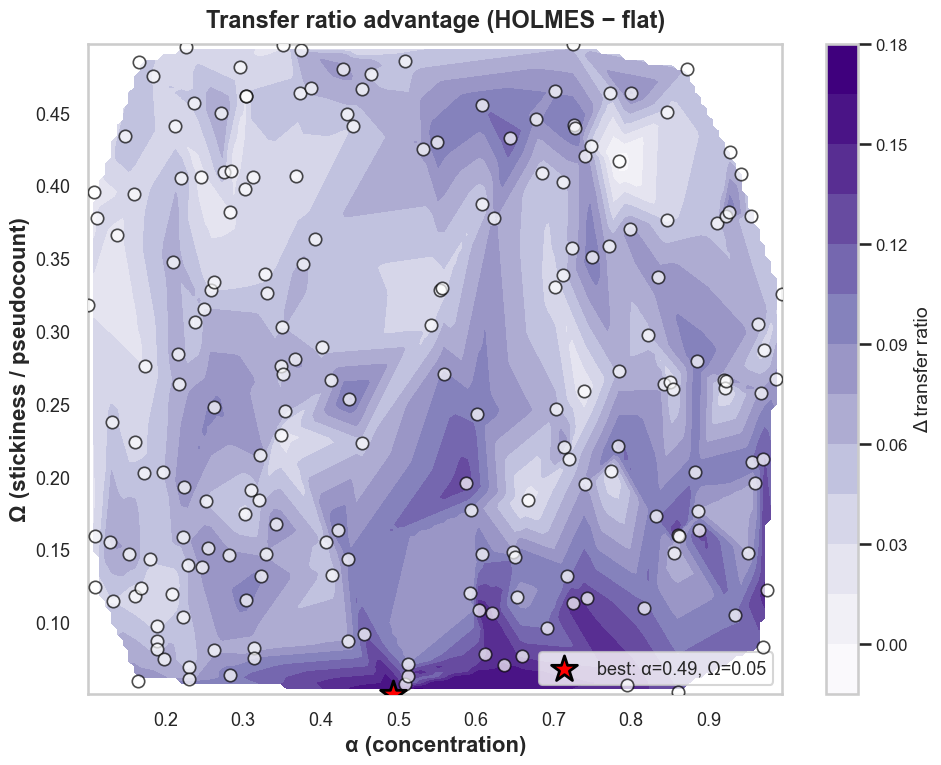

  [adv_heldout_brier_reduction] range [-0.0013, +0.0256], mean=+0.0095


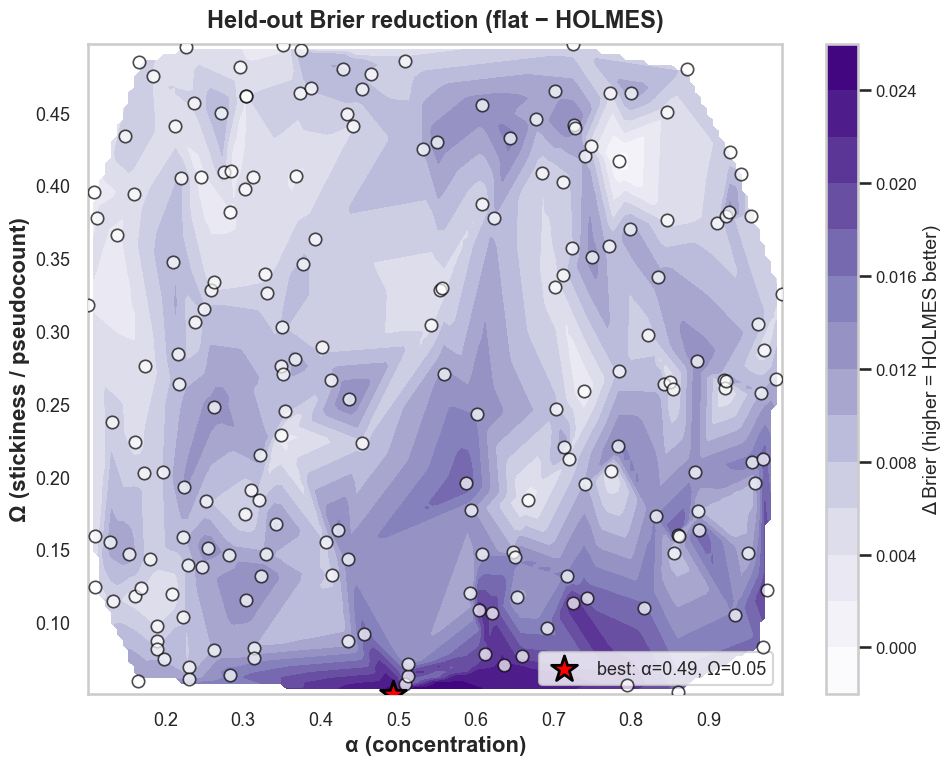

  [adv_first_heldout_acc] range [-0.0417, +0.5417], mean=+0.2379


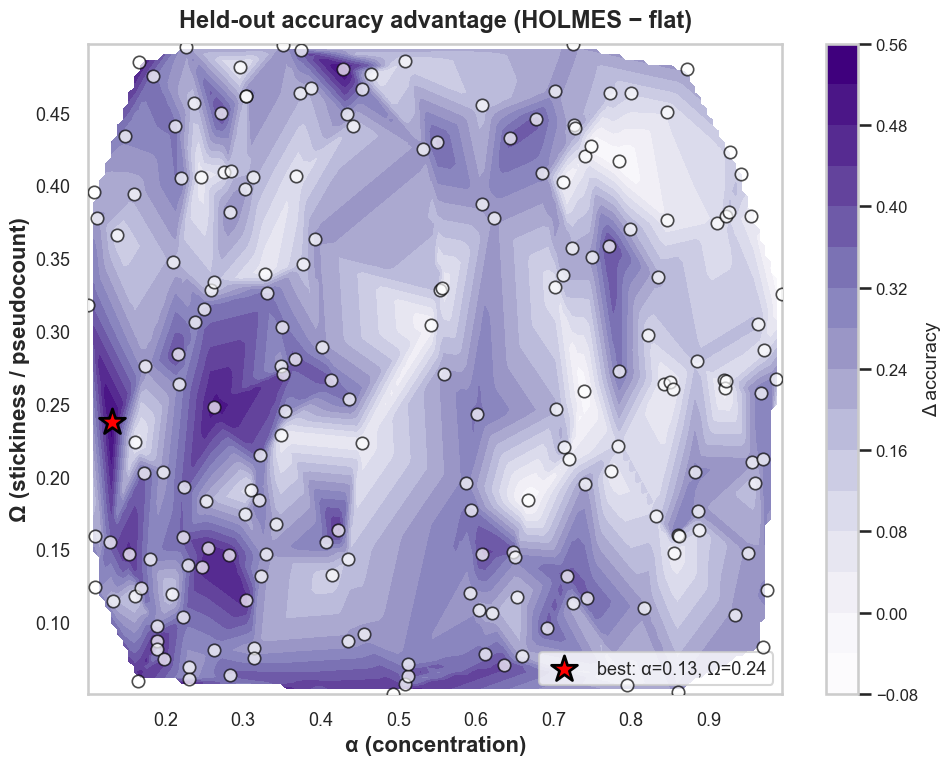

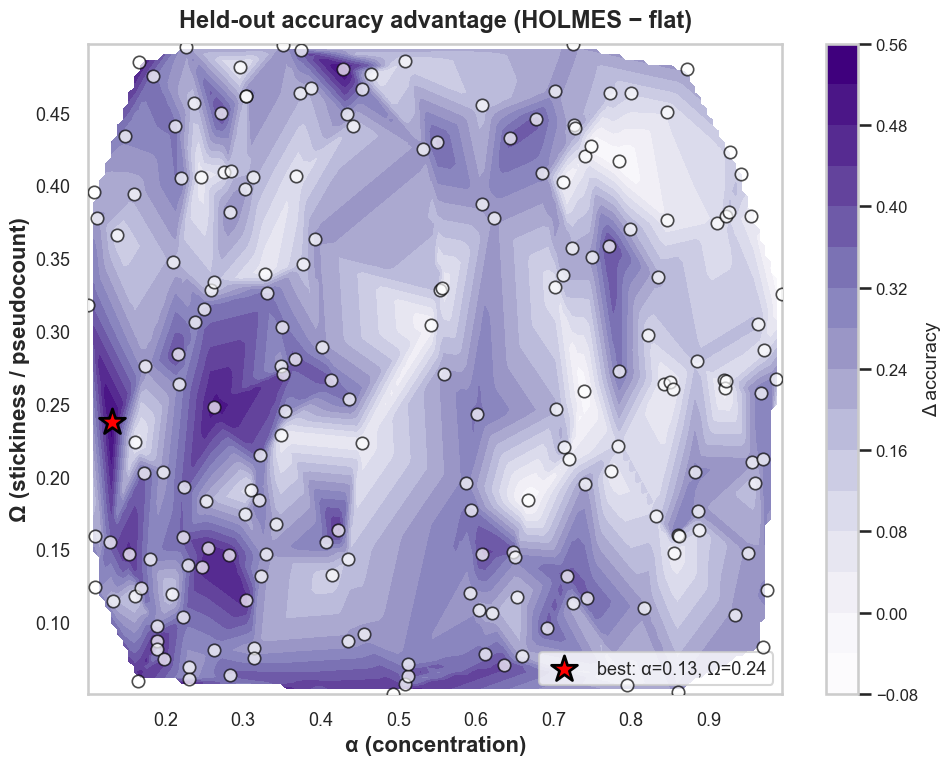

In [ ]:
# =====================================================================
# Heatmap function. Linear interpolation only-
# =====================================================================

def plot_param_heatmap(sweep_df, metric_col, title, cbar_label,
                       cmap='viridis', vmin=None, vmax=None,
                       mark_best=True, savepath=None):
    alpha_vals = sweep_df['alpha'].values
    omega_vals = sweep_df['omega'].values
    metric_vals = sweep_df[metric_col].values

    finite = np.isfinite(metric_vals)
    if finite.sum() < 4:
        print(f"  [{metric_col}] too few finite values ({finite.sum()}); skipping")
        return None
    data_min = float(np.nanmin(metric_vals))
    data_max = float(np.nanmax(metric_vals))
    print(f"  [{metric_col}] range [{data_min:+.4f}, {data_max:+.4f}], "
          f"mean={np.nanmean(metric_vals):+.4f}")

    alpha_grid = np.linspace(alpha_vals.min(), alpha_vals.max(), 120)
    omega_grid = np.linspace(omega_vals.min(), omega_vals.max(), 120)
    a_mesh, o_mesh = np.meshgrid(alpha_grid, omega_grid)
    m_mesh = griddata((alpha_vals[finite], omega_vals[finite]),
                      metric_vals[finite], (a_mesh, o_mesh), method='linear')
    m_mesh = np.clip(m_mesh, data_min, data_max)

    if vmin is None: vmin = data_min
    if vmax is None: vmax = data_max

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.contourf(a_mesh, o_mesh, m_mesh, levels=15, cmap=cmap,
                     vmin=vmin, vmax=vmax)
    cb = plt.colorbar(im, ax=ax)
    cb.set_label(cbar_label, fontsize=14)
    cb.ax.tick_params(labelsize=12)

    ax.scatter(alpha_vals, omega_vals, c='white', s=80,
               edgecolors='black', linewidth=1.2, alpha=0.7, zorder=10)

    if mark_best and finite.any():
        best_idx = int(np.nanargmax(metric_vals))
        ax.scatter(alpha_vals[best_idx], omega_vals[best_idx],
                   c='red', s=380, marker='*', edgecolors='black',
                   linewidth=2, zorder=11,
                   label=f'best: α={alpha_vals[best_idx]:.2f}, '
                         f'Ω={omega_vals[best_idx]:.2f}')
        ax.legend(fontsize=13, frameon=True)

    ax.set_xlabel('α (concentration)', fontsize=16, fontweight='bold')
    ax.set_ylabel('Ω (stickiness / pseudocount)', fontsize=16, fontweight='bold')
    ax.set_title(title, fontsize=17, fontweight='bold', pad=12)
    ax.tick_params(labelsize=13)
    ax.grid(alpha=0.2, color='white', linewidth=0.5)
    plt.tight_layout()
    if savepath:
        fig.savefig(savepath, bbox_inches='tight', dpi=150)
        fig.savefig(os.path.splitext(savepath)[0] + '.pdf', bbox_inches='tight')
    plt.show()
    return fig

# Primary normalized metric.
plot_param_heatmap(sweep, 'adv_transfer_ratio',
                   title='Transfer ratio advantage (HOLMES − flat)',
                   cbar_label='Δ transfer ratio',
                   cmap='Purples',
                   savepath='plots/heatmap_transfer_ratio_adv.png')

# Brier reduction.
plot_param_heatmap(sweep, 'adv_heldout_brier_reduction',
                   title='Held-out Brier reduction (flat − HOLMES)',
                   cbar_label='Δ Brier (higher = HOLMES better)',
                   cmap='Purples',
                   savepath='plots/heatmap_brier_reduction.png')

# Accuracy advantage.
plot_param_heatmap(sweep, 'adv_first_heldout_acc',
                   title='Held-out accuracy advantage (HOLMES − flat)',
                   cbar_label='Δ accuracy',
                   cmap='Purples',
                   savepath='plots/heatmap_accuracy_advantage.png')

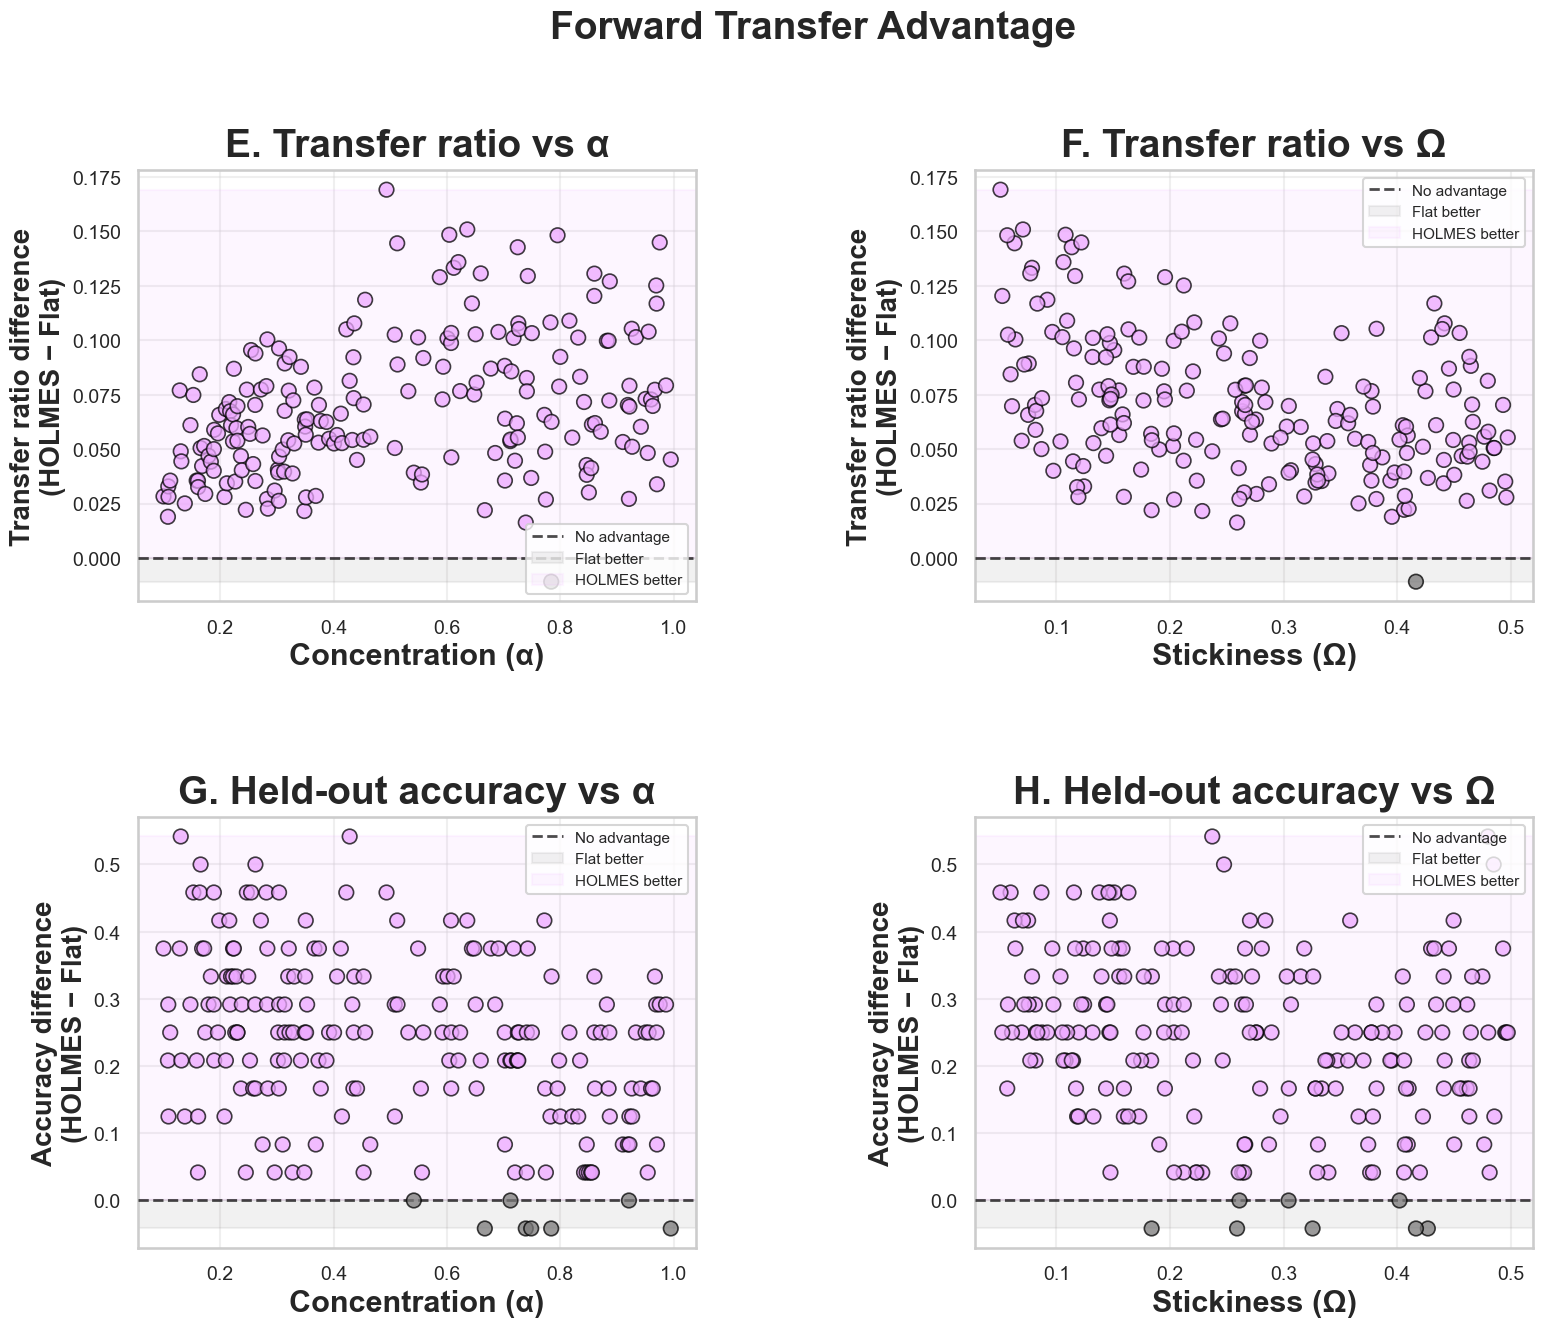

In [18]:
# =====================================================================
# Four-panel parameter-robustness figure 
#   rows: TRANSFER RATIO, HELD-OUT ACCURACY
#   cols: vs alpha, vs omega
# =====================================================================

def robustness_panel(ax, x, y, xlabel, ylabel, title,
                       color_hier=COLOR_HIER_LIGHT,
                       color_flat=COLOR_FLAT_LIGHT, legend_loc = 'lower right'):
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    if len(y) < 2:
        ax.text(0.5, 0.5, 'insufficient data', transform=ax.transAxes,
                ha='center', va='center')
        return

    colors = [color_hier if v > 0 else color_flat for v in y]
    ax.scatter(x, y, c=colors, alpha=0.75, s=110,
               edgecolors='black', linewidth=1.2, zorder=5)
    ax.axhline(0, color='black', linestyle='--', linewidth=2,
               alpha=0.7, label='No advantage', zorder=4)
    y_min, y_max = float(np.min(y)), float(np.max(y))
    if y_min < 0:
        ax.axhspan(y_min, 0, alpha=0.10, color=color_flat,
                   label='Flat better', zorder=1)
    if y_max > 0:
        ax.axhspan(0, y_max, alpha=0.10, color=color_hier,
                   label='HOLMES better', zorder=1)

    t_stat, p_val = stats.ttest_1samp(y, 0.0)
    sd = float(np.std(y, ddof=1))
    d = float(np.mean(y) / sd) if sd > 0 else np.nan
    pct = 100.0 * float(np.mean(y > 0))
    # ax.text(0.04, 0.96,
    #         f'{pct:.0f}% favor HOLMES\n'
    #         f'mean={np.mean(y):+.3f}\n'
    #         f't({len(y)-1})={t_stat:+.2f}, p={p_val:.1e}\n'
    #         f'd={d:+.2f}',
    #         transform=ax.transAxes, fontsize=11, fontweight='bold',
    #         verticalalignment='top',
    #         bbox=dict(boxstyle='round', facecolor='white',
    #                   alpha=0.92, edgecolor='black', linewidth=1.3))
    ax.legend(fontsize=11, loc=legend_loc, frameon=True)

    ax.set_xlabel(xlabel, fontsize=22, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=20, fontweight='bold')
    ax.set_title(title, fontsize=28, fontweight='bold', pad=10)
    ax.tick_params(axis='both', labelsize=14)
    ax.grid(alpha=0.3)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
alphas = sweep['alpha'].values
omegas = sweep['omega'].values

robustness_panel(axes[0, 0], alphas, sweep['adv_transfer_ratio'].values,
                   'Concentration (α)',
                   'Transfer ratio difference\n(HOLMES − Flat)',
                   'E. Transfer ratio vs α', legend_loc='upper left')
robustness_panel(axes[0, 1], omegas, sweep['adv_transfer_ratio'].values,
                   'Stickiness (Ω)',
                   'Transfer ratio difference\n(HOLMES − Flat)',
                   'F. Transfer ratio vs Ω', legend_loc='upper right')
robustness_panel(axes[1, 0], alphas, sweep['adv_first_heldout_acc'].values,
                   'Concentration (α)',
                   'Accuracy difference\n(HOLMES − Flat)',
                   'G. Held-out accuracy vs α', legend_loc='upper right')
robustness_panel(axes[1, 1], omegas, sweep['adv_first_heldout_acc'].values,
                   'Stickiness (Ω)',
                   'Accuracy difference\n(HOLMES − Flat)',
                   'H. Held-out accuracy vs Ω', legend_loc='upper right')

axes[0, 0].legend(fontsize=11, loc='lower right', frameon=True)

fig.suptitle('Forward Transfer Advantage',
                fontsize=28, fontweight='bold', y=0.995)
fig.subplots_adjust(hspace=0.5, wspace=0.5)

plt.show()

In [19]:
# =====================================================================
# Final summary table across all robustness metrics.
# Each row: metric, mean ± SEM, % positive combinations, t-test vs 0, Cohen's d.
# =====================================================================
summary_rows = []
for col, label in [
    ('adv_transfer_ratio',          'Transfer ratio advantage'),
    ('adv_first_heldout_acc',       'Held-out accuracy advantage'),
    ('adv_heldout_brier_reduction', 'Brier reduction (flat−HOLMES)'),
    ('adv_heldout_signed_contrast', 'Signed contrast advantage'),
]:
    if col not in sweep.columns: continue
    vals = sweep[col].dropna()
    if len(vals) < 2: continue
    t, p = stats.ttest_1samp(vals, 0.0)
    sd = float(vals.std(ddof=1))
    d = float(vals.mean() / sd) if sd > 0 else np.nan
    summary_rows.append({
        'metric': label,
        'mean': float(vals.mean()),
        'sem': float(stats.sem(vals)),
        'pct_positive': 100.0 * float((vals > 0).mean()),
        'n_combos': int(len(vals)),
        't': float(t),
        'p': float(p),
        'd': d,
    })
summary = pd.DataFrame(summary_rows)
with pd.option_context('display.float_format', '{:+.4f}'.format):
    print(summary.to_string(index=False))
summary.to_csv('plots/robustness_summary.csv', index=False)
print('\nSaved summary table → plots/robustness_summary.csv')

                       metric    mean     sem  pct_positive  n_combos        t       p       d
     Transfer ratio advantage +0.0691 +0.0023      +99.5000       200 +30.6427 +0.0000 +2.1668
  Held-out accuracy advantage +0.2379 +0.0091      +96.0000       200 +26.2084 +0.0000 +1.8532
Brier reduction (flat−HOLMES) +0.0095 +0.0003      +99.5000       200 +28.9647 +0.0000 +2.0481
    Signed contrast advantage +0.0195 +0.0007      +99.5000       200 +28.5370 +0.0000 +2.0179

Saved summary table → plots/robustness_summary.csv


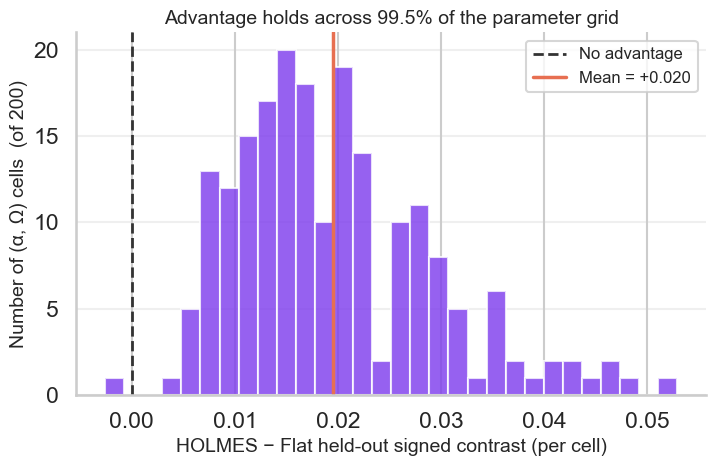

In [20]:
# ---------------------------------------------------------------------
# PLOT 3 — robustness across the (alpha, omega) grid.
# Histogram of the per-cell HOLMES-minus-flat held-out signed contrast over
# all 200 sampled parameter cells (seeds averaged within cell). The mass
# sitting above zero is the "not tuned" argument: the advantage holds across
# ~99.5% of the parameter grid, not just at the reported operating point.
# Requires `sweep` = the 200-cell shape/color sweep DataFrame.
# ---------------------------------------------------------------------
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
os.makedirs('plots', exist_ok=True)
COLOR_HIER = globals().get('COLOR_HIER', '#7C3AED')

def plot_grid_robustness():
    if 'sweep' not in globals():
        raise NameError("Load the sweep first: sweep = pd.read_csv('shape_color_sweep_...per_seed.csv')")
    cell = (sweep.groupby(['alpha', 'omega'])['adv_heldout_signed_contrast']
                 .mean().reset_index())
    adv = cell['adv_heldout_signed_contrast'].values
    frac_pos = (adv > 0).mean() * 100

    fig, ax = plt.subplots(figsize=(7.5, 5))
    ax.hist(adv, bins=30, color=COLOR_HIER, alpha=0.8, edgecolor='white')
    ax.axvline(0, color='#333', ls='--', lw=2, label='No advantage')
    ax.axvline(adv.mean(), color='#E76F51', lw=2.5, label=f'Mean = {adv.mean():+.3f}')
    ax.set_xlabel('HOLMES − Flat held-out signed contrast (per cell)', fontsize=14)
    ax.set_ylabel(f'Number of (α, Ω) cells  (of {len(cell)})', fontsize=14)
    ax.set_title(f'Advantage holds across {frac_pos:.1f}% of the parameter grid', fontsize=14)
    ax.legend(fontsize=12)
    ax.spines[['top', 'right']].set_visible(False); ax.grid(alpha=0.3, axis='y')
    fig.tight_layout()
    fig.savefig('plots/fig4_grid_robustness.png', dpi=200, bbox_inches='tight')
    fig.savefig('plots/fig4_grid_robustness.pdf', bbox_inches='tight')
    plt.show()

plot_grid_robustness()

In [21]:
print([c for c in sweep.columns if 'level' in c.lower() or 'node' in c.lower() or 'shape' in c.lower()])

[]


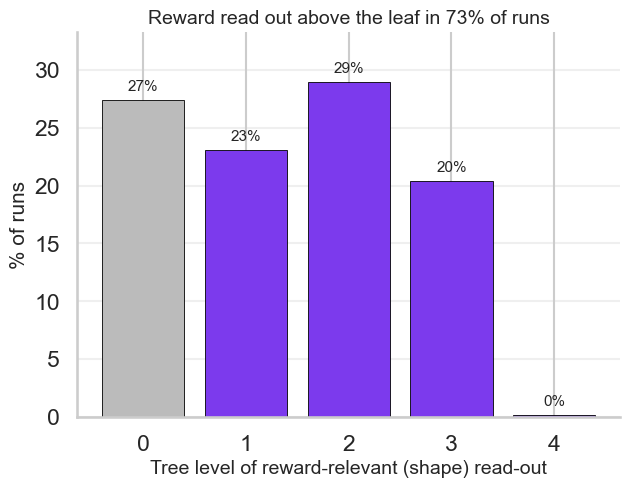

In [23]:
# ---------------------------------------------------------------------
# PLOT 4 — mechanism: tree level of the reward-relevant (shape) read-out.
# Uses sweep_raw (per-seed), because `sweep` is aggregated and drops this column.
# ---------------------------------------------------------------------
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
os.makedirs('plots', exist_ok=True)
COLOR_HIER = globals().get('COLOR_HIER', '#7C3AED')

def plot_tree_level():
    src = sweep_raw if 'sweep_raw' in globals() else sweep
    if 'hier_best_shape_level' not in src.columns:
        raise KeyError("hier_best_shape_level not found in sweep_raw. "
                       "Columns: " + str([c for c in src.columns if 'level' in c.lower()]))
    lv = src['hier_best_shape_level'].dropna().astype(int).values
    levels = np.arange(lv.min(), lv.max() + 1)
    fracs = np.array([(lv == k).mean() for k in levels]) * 100
    above_leaf = (lv > 0).mean() * 100

    fig, ax = plt.subplots(figsize=(7, 5))
    colors = ['#bbbbbb'] + [COLOR_HIER] * (len(levels) - 1)   # root grey, deeper purple
    ax.bar(levels, fracs, color=colors, edgecolor='black', linewidth=0.6)
    ax.set_xlabel('Tree level of reward-relevant (shape) read-out', fontsize=14)
    ax.set_ylabel('% of runs', fontsize=15)
    ax.set_title(f'Reward read out above the leaf in {above_leaf:.0f}% of runs', fontsize=14)
    ax.set_xticks(levels)
    for k, f in zip(levels, fracs):
        ax.text(k, f + 0.8, f'{f:.0f}%', ha='center', fontsize=11)
    ax.spines[['top', 'right']].set_visible(False); ax.grid(alpha=0.3, axis='y')
    ax.set_ylim(0, max(fracs) * 1.15)
plot_tree_level()